# CA1 Data Preparation – Student Dataset

## 1. Introduction

This notebook describes how the preparation and Exploratory Data Analysis (EDA) of the dataset relevant to the task was carried out.
The central focus of this investigation is to cleanse and organize the data so that, through the categorical variable "Target," it is possible to understand the three possible outcomes for students: school dropout, remaining in studies, or graduation.

This analysis is structured into the following components:

1. Dataset description.
2. Initial data quality assessment.
3. Data cleaning and preparation.
4. EDA.
5. Principal Component Analysis (PCA)
6. Practical application testing
7. Conclusions
8. The 'Curse of Dimensionality' concept
9. References.

## 2. Importing libraries

In [62]:
# Import pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as preproc

## 3. Dataset characterisation

This section aims to characterize the dataset thoroughly, detailing its overall dimensions, its internal structure, and its initial state before any cleaning operations are performed. A clear understanding of these preliminary attributes is essential, as it provides the context for subsequent decisions regarding data preprocessing within this notebook.

In [63]:
# Load dataset and preview first 5 rows

student_df = pd.read_csv('student_data.csv')
student_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [64]:
# Shape of dataset

print("Dataset shape (rows,columns):",student_df.shape)
print("Number of variables including Target:",student_df.shape[1])
print("Number of observations",student_df.shape[0])

Dataset shape (rows,columns): (4424, 37)
Number of variables including Target: 37
Number of observations 4424


In [65]:
print("Number of unique categories in Target", student_df.Target.nunique())

print("Target labels found",student_df['Target'].unique())

Number of unique categories in Target 7
Target labels found ['Dropout' 'Graduate' 'Enrolled' 'Grad' 'graduate' 'Drop' 'dropout']


In [66]:
# information about dataset
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [67]:
# Checking existing missing values
student_df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            1
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            1
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   1
Displaced                                         0
Educational special needs                         0
Debtor                                            1
Tuition fees up to date                           1
Gender                                            0
Scholarship holder                                0
Age at enrol

### Characterisation summary

This dataset has **4,424 entries (observations)** and **37 different columns (variables)**, including the main **'Target'** variable.
The datasete has a few common problems that it needs to sort out, like:

- Missing information,
- The 'Target' variable having some categories labeled differently when they should be the same,
- Some columns are stored in a way that does not exactly correspond to their meaning according to the student_data_dictionary document.

After analyzing these points, it became evident that this dataframe needs to be corrected before any proper analysis or attempt to simplify the data.

## 4. Initial data quality assessment

The purpose of this section is to identify missing values, hidden missing values, and variables that may require type correction.

In [68]:
# Checking unique values to identify hidden missing data
student_df['Course'].unique()

array([ 171., 9254., 9070., 9773., 8014., 9991., 9500., 9238., 9670.,
       9853., 9085., 9130., 9556., 9147., 9003.,   33., 9119.,   nan])

In [69]:
student_df["Father's qualification"].unique()

array([12.,  3., 37., 38.,  1., 19.,  5.,  4., 34.,  2., 39., 11.,  9.,
       nan, 36., 26., 40., 14., 20., 35., 41., 22., 13., 29., 43., 18.,
       42., 10.,  6., 30., 25., 44., 33., 27., 31.])

In [70]:
student_df["Debtor"].unique()

array([ 0.,  1., nan])

In [71]:
student_df["Tuition fees up to date"].unique()

array(['1', '0', nan, '?'], dtype=object)

In [72]:
student_df["International"].unique()

array([ 0.,  1., nan])

In [73]:
student_df["Curricular units 2nd sem (enrolled)"].unique()

array([ 0.,  6.,  5.,  8.,  7., 11., 12.,  9., 13., 19.,  3., 10.,  4.,
       nan, 17.,  2.,  1., 14., 15., 16., 23., 18., 21.])

In [74]:
mv = ["n.a.","nan", "?", "NA", "n/a", "na", "--", "Unknown"]

In [75]:
# Converting non-standard missing value indicators (e.g., '?', 'Unknown') into NaN for consistency
student_df = pd.read_csv("student_data.csv", na_values=mv)

### Rationale for the quality checks

Objective of Data Quality Assessment

The objective of these assessments was to correct the anomalies previously mentioned, including:

- Missing, unidentified data points,
- Data recorded in an inappropriate format,
- Or inconsistent application of categorical labels across the dataset.

These corrections are vitally important to ensure that data quality is not compromised and thus the validity of subsequent analyses is not compromised. Specifically, this can lead to erroneous descriptive statistics, misleading graphical representations, and ultimately compromise the robustness of advanced analytical techniques such as Principal Component Analysis.

## 5. Data cleaning and preparation
The dataset was cleaned based on what each variable meant.

### Cleaning strategy used
**Categorical or coded categorical variables** were filled with missing values using the most common input. When dealing with **continuous numerical variables**, the median was used to replace any missing values. This helped ensure that extreme numbers did not significantly distort the results. For **count variables**, 0 was sometimes used where values were missing, assuming that this meant there was nothing there. The **target variables** names were also standardized because they were not consistent. Finally, some variables had the wrong data type, so it was changed to integers when it made sense (McKinney,2017) .

Below, you'll see a clean version of the original dataset.

In [76]:
# The initial dataset was copied for backup.
student_df_clean = student_df.copy()

Although several variables are stored as numerical values, many of them represent encoded categorical information (e.g., Marital status, Course, Gender). These variables were kept in their original format to preserve consistency with the dataset structure. However, their categorical nature was considered during the analysis and interpretation of the results.

In [77]:
student_df_clean['Marital status'] = student_df_clean['Marital status'].fillna(student_df_clean['Marital status'].mode()[0])
student_df_clean['Marital status'] = student_df_clean['Marital status'].astype('Int64')

Although stored as numeric, this variable represents encoded categories. Missing values were replaced using the mode to preserve the most frequent category and maintain dataset consistency.

In [78]:
student_df_clean['Course'] = student_df_clean['Course'].fillna(student_df_clean['Course'].mode()[0])
student_df_clean['Course'] = student_df_clean['Course'].astype('Int64')

This variable represents encoded categorical information. Missing values were replaced using the mode to maintain the most frequent category and ensure consistency.

In [79]:
student_df_clean["Father's qualification"] = student_df_clean["Father's qualification"].fillna(student_df_clean["Father's qualification"].mode()[0])
student_df_clean["Father's qualification"] = student_df_clean["Father's qualification"].astype('Int64')

This variable represents encoded categorical information but was stored as float due to a missing value. The missing value was replaced using the mode, and the variable was then converted to integer type to align with the data dictionary.

In [80]:
student_df_clean['Admission grade'] = student_df_clean['Admission grade'].fillna(student_df_clean['Admission grade'].median())

This variable represents a continuous numerical value (admission grade). Missing values were replaced using the median to reduce the impact of potential outliers.

In [81]:
student_df_clean['Displaced'] = student_df_clean['Displaced'].fillna(student_df_clean['Displaced'].mode()[0])
student_df_clean['Displaced'] = student_df_clean['Displaced'].astype('Int64')

This variable represents a binary categorical feature. Missing values were replaced using the mode, and the variable was converted to integer type to align with its encoded structure.

In [82]:
student_df_clean['Debtor'] = student_df_clean['Debtor'].fillna(student_df_clean['Debtor'].mode()[0])
student_df_clean['Debtor'] = student_df_clean['Debtor'].astype('Int64')

This variable represents a binary categorical feature. Missing values were replaced using the mode, and the variable was converted to integer type to ensure consistency with its encoded format.

In [83]:
student_df_clean['Tuition fees up to date'] = student_df_clean['Tuition fees up to date'].fillna(student_df_clean['Tuition fees up to date'].mode()[0])
student_df_clean['Tuition fees up to date'] = student_df_clean['Tuition fees up to date'].astype('Int64')

This variable represents a binary categorical feature. Missing values were replaced using the mode, and the variable was converted to integer type.

In [84]:
student_df_clean['Age at enrollment'] = pd.to_numeric(student_df_clean['Age at enrollment'], errors='coerce')
student_df_clean['Age at enrollment'] = student_df_clean['Age at enrollment'].fillna(student_df_clean['Age at enrollment'].median())

This variable was initially stored as an object due to non-standard values (e.g., "Unknown"). It was converted to numeric format, and missing values were replaced using the median.

In [85]:
student_df_clean['International'] = student_df_clean['International'].fillna(student_df_clean['International'].mode()[0])
student_df_clean['International'] = student_df_clean['International'].astype('Int64')

This variable represents a binary categorical feature. Missing values were replaced using the mode.

In [86]:
student_df_clean['Curricular units 1st sem (credited)'] = pd.to_numeric(student_df_clean['Curricular units 1st sem (credited)'], errors='coerce')
student_df_clean['Curricular units 1st sem (credited)'] = student_df_clean['Curricular units 1st sem (credited)'].fillna(0)
student_df_clean['Curricular units 1st sem (credited)'] = student_df_clean['Curricular units 1st sem (credited)'].astype('Int64')

This variable represents a count of credited units. It was converted from object to numeric format, and missing values were replaced with zero, as they likely indicate no credited units.

In [87]:
student_df_clean['Curricular units 1st sem (grade)'] = student_df_clean['Curricular units 1st sem (grade)'].fillna(student_df_clean['Curricular units 1st sem (grade)'].median())

This variable represents a continuous numerical value (grade). Missing values were replaced using the median to reduce the impact of potential outliers.

In [88]:
student_df_clean['Curricular units 2nd sem (enrolled)'] = student_df_clean['Curricular units 2nd sem (enrolled)'].fillna(0)
student_df_clean['Curricular units 2nd sem (enrolled)'] = student_df_clean['Curricular units 2nd sem (enrolled)'].astype('Int64')

This variable represents a count of enrolled units in the second semester. Missing values were replaced with zero, as they likely indicate no enrolled units, and the variable was converted to integer type.

In [89]:
student_df_clean['Curricular units 2nd sem (grade)'] = student_df_clean['Curricular units 2nd sem (grade)'].fillna(student_df_clean['Curricular units 2nd sem (grade)'].median())

This variable represents a continuous numerical value (grade). Missing values were replaced using the median to reduce the impact of potential outliers.

In [90]:
student_df_clean['Target'] = student_df_clean['Target'].replace({
    'Grad': 'Graduate',
    'graduate': 'Graduate',
    'Drop': 'Dropout',
    'dropout': 'Dropout'
})

In [91]:
student_df_clean['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [92]:
student_df_clean['Target'] = student_df_clean['Target'].astype('category')

The **target variable** represents categorical student outcomes (Dropout, Enrolled, and Graduate). During the cleaning process, inconsistent labels such as different capitalizations and abbreviations were standardised to ensure category consistency and prevent misleading results in the analysis. After this standardisation, the variable was converted to a categorical data type to improve interpretability and better reflect its role in the dataset.

### Why these transformations were appropriate

We decided how to handle the cleaning by looking at what each piece of information (variable) was meant to do in our dataset (McKinney, 2017 ):

- For **categorical variables** that were already turned into numbers, we filled in any missing spots with the most common value (the mode). This helped us make sure that the count of the most frequent category stayed accurate.

- When we had **continuous variables**, it was better to fill in gaps using the middle value (the median). This is because the median is usually a more reliable choice than the average when the data is lopsided or has some extreme high or low values.

- If we were dealing with **count-type variables**, like how many credits or units someone had, and a value was missing, we just put a zero. It made sense to assume that a missing number in these cases simply meant there weren't any.

- And finally, standardizing our **target variable** (the main thing we were trying to predict) was really important. We had to do this to prevent the same category from accidentally splitting into several different labels, which would have messed up our counts and any further analysis.

## 6. Post-cleaning validation

After the cleaning stage, the dataset should be checked again to confirm that the selected issues were corrected.

In [93]:
student_df_clean.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [94]:
student_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital status                                  4424 non-null   Int64   
 1   Application mode                                4424 non-null   int64   
 2   Application order                               4424 non-null   int64   
 3   Course                                          4424 non-null   Int64   
 4   Daytime/evening attendance                      4424 non-null   int64   
 5   Previous qualification                          4424 non-null   int64   
 6   Previous qualification (grade)                  4424 non-null   float64 
 7   Nacionality                                     4424 non-null   int64   
 8   Mother's qualification                          4424 non-null   int64   
 9   Father's qualification        

In [95]:
student_df_clean["Target"].unique()

['Dropout', 'Graduate', 'Enrolled']
Categories (3, object): ['Dropout', 'Enrolled', 'Graduate']

### Post-cleaning summary

The dataset became much more consistent after we cleaned it up. This involved making sure all the labels were the same, correcting some of the data types, and filling in any missing values with approaches that made sense for each specific kind of data.
Now, the data is in good shape for us to start exploring it and, later, for making it simpler by reducing its dimensions.

## 7. EDA

Following the completion of data cleaning, the dataset is subsequently prepared for exploratory analysis. The purpose of this phase is to uncover inherent patterns, examine data distributions, and determine the interrelationships among various variables.

It should be noted that a selective approach was adopted for visualization. This decision was based on prioritizing variables that demonstrated the highest relevance in elucidating student outcomes (Kuhn and Johnson, 2019; Dasu and Johnson, 2003). Specifically, preference was given to those variables possessing enhanced interpretability and a discernible potential to influence the target.

- **Target**: to understand class distribution,
- **Age at enrollment**: to examine demographic patterns,
- **Admission grade**: to explore prior academic performance,
- **Debtor** and **Tuition fees up to date**: to investigate financial factors,
- **Curricular units 1st sem (approved)**: to assess academic progression.

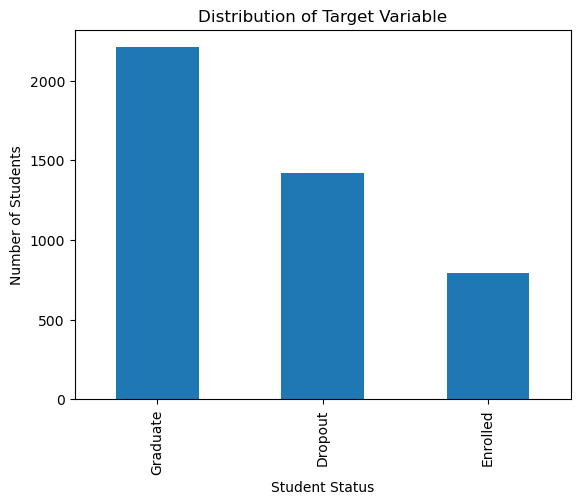

In [96]:
# Distribution of the target variable
student_df_clean['Target'].value_counts().plot(kind='bar')

plt.title("Distribution of Target Variable")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")

plt.show()

The distribution of **the target variable** shows that the majority of students successfully graduated.

It can also be observed that the number of students who dropped out is higher than the number of students currently enrolled, indicating that dropout is a significant outcome in the dataset. Additionally, the distribution is not balanced, with a noticeably smaller number of enrolled students. This may suggest that most students have already reached a final outcome (either graduation or dropout), which is important to consider in further analysis.

After analyzing the target variable, the next step is to explore potential factors that may influence student outcomes, such as **age at enrollment**.

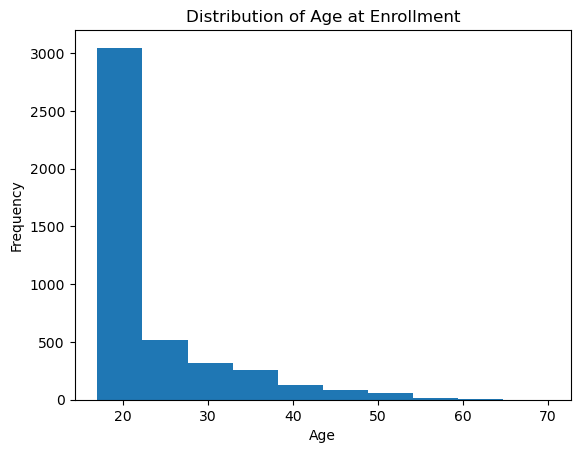

In [97]:
student_df_clean['Age at enrollment'].plot(kind='hist')
plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**The distribution of age at enrollment** shows that the majority of students are in their early twenties. There are very few students above the age of 50, indicating that the dataset is predominantly composed of younger individuals.The distribution appears to be right-skewed, with most values concentrated at lower ages and a small number of higher-age outliers. This suggests that the student population is relatively homogeneous in terms of age, with only a few non-traditional students. This pattern is important for further analysis, as age may influence student outcomes such as dropout or graduation.

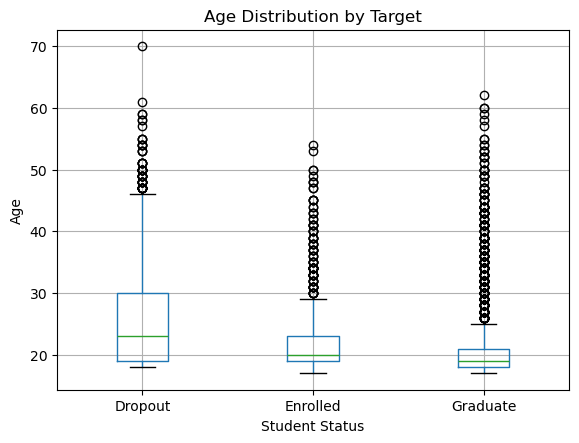

In [98]:
student_df_clean.boxplot(column='Age at enrollment', by='Target')

plt.title("Age Distribution by Target")
plt.suptitle("")  # remove título automático
plt.xlabel("Student Status")
plt.ylabel("Age")

plt.show()

The boxplot shows clear differences in **age distribution** across the three groups.

Students who dropped out exhibit a wider spread of values, indicating greater variability in age. In contrast, students who graduated have a more compact distribution, suggesting that their ages are more consistent. The median age of students who dropped out is higher than that of the other groups, indicating that older students may be more likely to leave the course before completion. Additionally, the presence of multiple outliers in all groups suggests that there are some non-traditional students, particularly among those who dropped out. Overall, this analysis suggests that age may be an important factor influencing student outcomes.

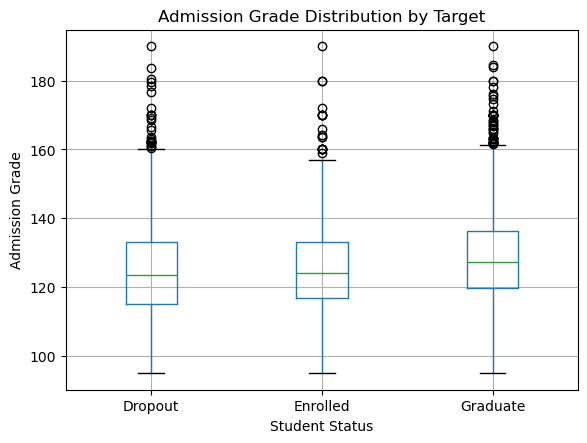

In [99]:
student_df_clean.boxplot(column='Admission grade', by='Target')

plt.title("Admission Grade Distribution by Target")
plt.suptitle("")
plt.xlabel("Student Status")
plt.ylabel("Admission Grade")

plt.show()

The boxplot shows that students who graduated tend to have slightly higher admission grades compared to the other groups. However, the differences between the groups are relatively small, and the distributions are quite similar, with significant overlap across all categories. Although the median grade is highest for graduates, the difference is not substantial, suggesting that admission grade alone may not be a strong predictor of student outcomes. All groups show considerable variability, indicating a wide range of grades within each category. Additionally, enrolled students appear to have fewer extreme values compared to the other groups. Overall, this suggests that while admission grade may have some influence, other factors are likely to play a more significant role in determining whether a student graduates or drops out.

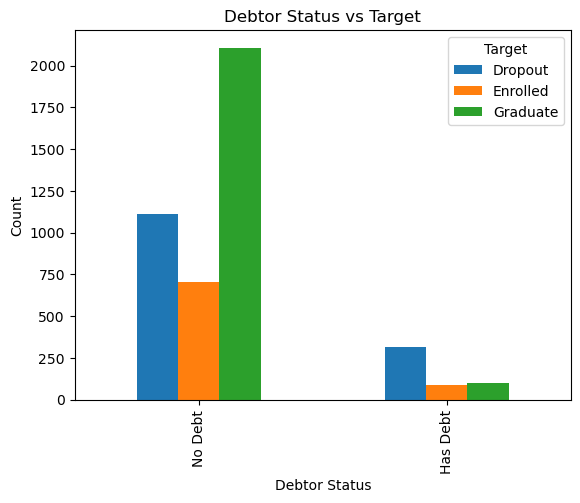

In [100]:
ax = pd.crosstab(student_df_clean['Debtor'], student_df_clean['Target']).plot(kind='bar')

ax.set_xticklabels(['No Debt', 'Has Debt'])

plt.title("Debtor Status vs Target")
plt.xlabel("Debtor Status")
plt.ylabel("Count")

plt.show()

The variable "Debtor" is a binary feature, where 0 represents students without debt and 1 represents students with debt. The chart shows that most students are not in debt. However, among students with debt, there appears to be a higher proportion of dropouts. This suggests that financial difficulties may be associated with a higher likelihood of leaving the course before completion.

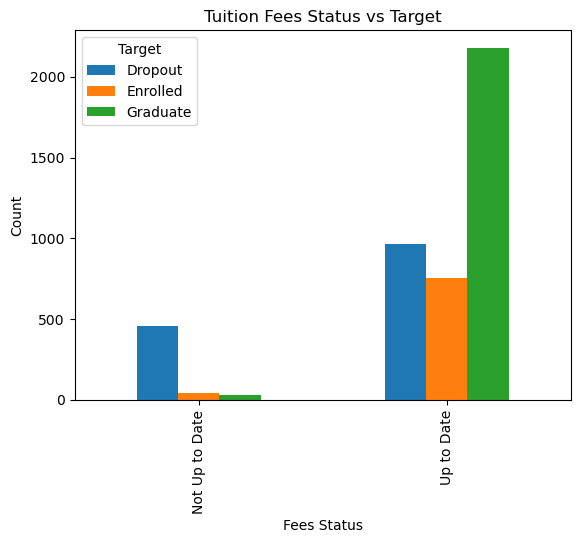

In [101]:
ax = pd.crosstab(student_df_clean['Tuition fees up to date'], student_df_clean['Target']).plot(kind='bar')

ax.set_xticklabels(['Not Up to Date', 'Up to Date'])

plt.title("Tuition Fees Status vs Target")
plt.xlabel("Fees Status")
plt.ylabel("Count")

plt.show()

The variable **Tuition fees up to date** is a binary feature, where 0 represents students who are not up to date with their fees and 1 represents those who are. The chart shows a clear relationship between financial status and student outcomes. Students who are not up to date with their fees are much more likely to drop out, with very few reaching graduation. In contrast, students who are up to date with their fees have a significantly higher number of graduates and fewer dropouts. This suggests that financial stability plays a crucial role in student success and may be a stronger predictor of outcomes than academic factors such as admission grade.

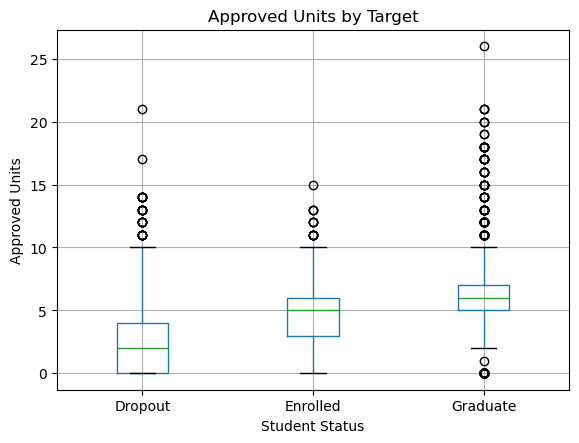

In [102]:
student_df_clean.boxplot(column='Curricular units 1st sem (approved)', by='Target')

plt.title("Approved Units by Target")
plt.suptitle("")
plt.xlabel("Student Status")
plt.ylabel("Approved Units")

plt.show()

The boxplot shows clear differences in the number of approved curricular units across the three groups.

Students who graduated have a higher number of approved units, while students who dropped out have significantly fewer. Enrolled students fall between these two groups.
The median values increase consistently from dropout to enrolled to graduate, indicating a clear relationship between academic performance and student outcomes.
Compared to admission grade, the differences between groups are more pronounced, suggesting that performance during the course is a stronger indicator of success than initial academic background.
Overall, this analysis highlights the importance of ongoing academic performance in determining whether a student completes the course.

The analysis focused on variables that are most likely to influence student outcomes, including financial factors and academic performance. These variables were selected to better understand the potential reasons behind dropout and graduation.

## 8. Conclusion of EDA

The exploratory data analysis provided important insights into the factors influencing student outcomes.

- The distribution of the target variable revealed that most students graduate, although a significant number of students drop out, highlighting the importance of understanding the factors behind this outcome.

- Age appeared to play some role, as older students tended to be more prone to dropping out. However, these differences were only moderate, suggesting that age on its own is not a powerful predictor.

- Admission grades showed only minor differences between groups, which suggests that initial academic performance does not significantly determine a student's success.

- In contrast, financial factors, such as having debtor status or unpaid tuition fees, exhibited a strong connection with student outcomes. Students experiencing financial hardship were considerably more likely to drop out, which suggests that financial stability plays a crucial role in student retention.

- Academic performance during the course, specifically the number of approved curricular units, showed the most significant relationship with the target variable. Students who approved more units demonstrated a much higher likelihood of graduating, while those with fewer approved units were more prone to dropping out.

Overall, the analysis suggests that a student's ongoing academic performance and financial situation are more significant predictors of student success than initial characteristics like admission grade or age.

## 9. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) serves as a method for dimensionality reduction, aiming to decrease the number of features within a dataset. The fundamental principle is to achieve this reduction while carefully preserving the greatest possible proportion of the dataset's variance. For this particular dataset, PCA will be utilized to determine the minimum number of principal components necessary to account for at least 99.5% of the total variance. This approach facilitates a substantial simplification of the dataset without compromising most of the critical underlying information. Reducing dimensionality can lead to improved computational efficiency. Moreover, it contributes to mitigating potential challenges such as overfitting, which might otherwise impair model performance (Jolliffe, 2002; James et al., 2021).

### Explained variance plot

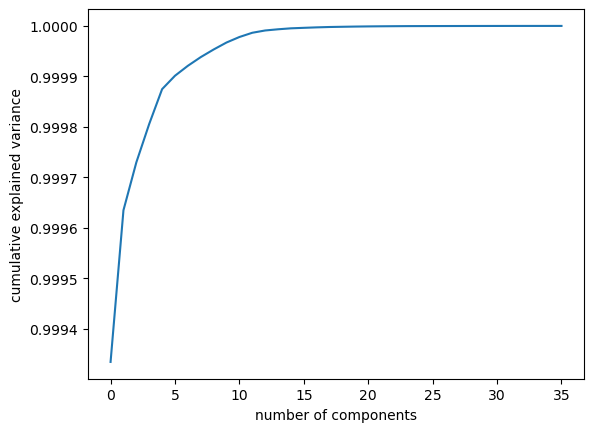

In [103]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

student_no_label = student_df_clean.drop(columns=["Target"])
pca = PCA().fit(student_no_label) 
plt.plot(np.cumsum(pca.explained_variance_ratio_)) 
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance'); 

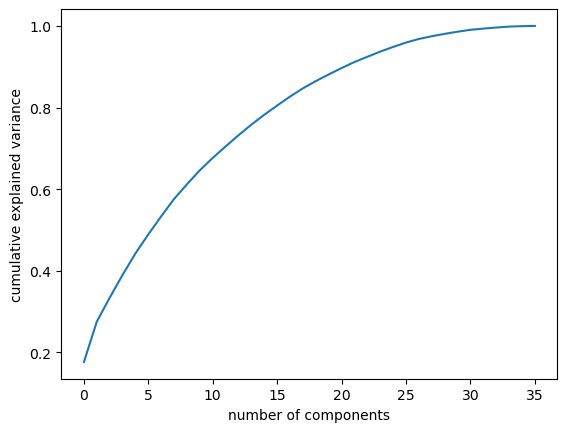

In [104]:
# Scale data
student_scaler = StandardScaler()
student_scaled = student_scaler.fit_transform(student_no_label)

pca_scaled = PCA().fit(student_scaled)

plt.plot(np.cumsum(pca_scaled.explained_variance_ratio_)) # Cumulative variance
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');


In [105]:
# Cumulative variance
cumulative_variance = np.cumsum(pca_scaled.explained_variance_ratio_)

# Find number of components for 99.5%
n_components = np.argmax(cumulative_variance >= 0.995) + 1

print("Number of components to retain 99.5% variance:", n_components)

Number of components to retain 99.5% variance: 33


In [106]:
new_pca = PCA(n_components).fit_transform(student_scaled)
print("New dataset shape:", new_pca.shape)


New dataset shape: (4424, 33)


While it may appear that employing Principal Component Analysis without prior standardization results in fewer components being necessary to retain 99.5% of the variance, this finding can be misleading. Principal Component Analysis is notably sensitive to the inherent scale of the data. Consequently, variables that exhibit broader numerical ranges tend to exert a dominant influence on the analysis when the dataset is not appropriately standardized. Upon applying a scaling technique, such as StandardScaler, the variance is distributed more uniformly across all features. This equitable distribution then necessitates a greater number of components to achieve the 99.5% variance threshold, thereby providing a more accurate and representative view of the dataset. Therefore, standardization is fundamental to ensuring that all variables contribute equally and appropriately to the derived PCA results.

### PCA scatter plot (PC1 vs PC2)

While all components collectively account for the entire variance, their complete inclusion is not always requisite for analytical objectives. The cumulative explained variance plot indicates that a more modest set of components, typically between 10 and 20, proves adequate for preserving a significant majority of the dataset's intrinsic information. For the purpose of visual representation, only the initial two principal components were employed. This selection is justified by their capacity to capture the highest proportion of variance, thereby enabling a two-dimensional depiction of the data (**referência**)

In [107]:
pca_scatter = PCA(4).fit_transform(student_scaled)
print("New dataset shape:", pca_scatter.shape)

pca_df = pd.DataFrame(pca_scatter, columns =['PC1', 'PC2', 'PC3', 'PC4'])
pca_df.head()

New dataset shape: (4424, 4)


,PC1,PC2,PC3,PC4
0,-6.100726,-0.296112,-1.422994,0.458880
1,-0.254748,-1.107109,-1.845765,0.610970
2,-3.956116,0.446716,0.011257,0.105097
3,0.422154,-0.959041,0.887183,-1.044143
4,0.407749,2.791887,1.899098,-1.964938


In [108]:
pca_df["Target"] = student_df_clean["Target"]
pca_df.head()

,PC1,PC2,PC3,PC4,Target
0,-6.100726,-0.296112,-1.422994,0.458880,Dropout
1,-0.254748,-1.107109,-1.845765,0.610970,Graduate
2,-3.956116,0.446716,0.011257,0.105097,Dropout
3,0.422154,-0.959041,0.887183,-1.044143,Graduate
4,0.407749,2.791887,1.899098,-1.964938,Graduate


In [109]:
pca_df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'Target'], dtype='object')

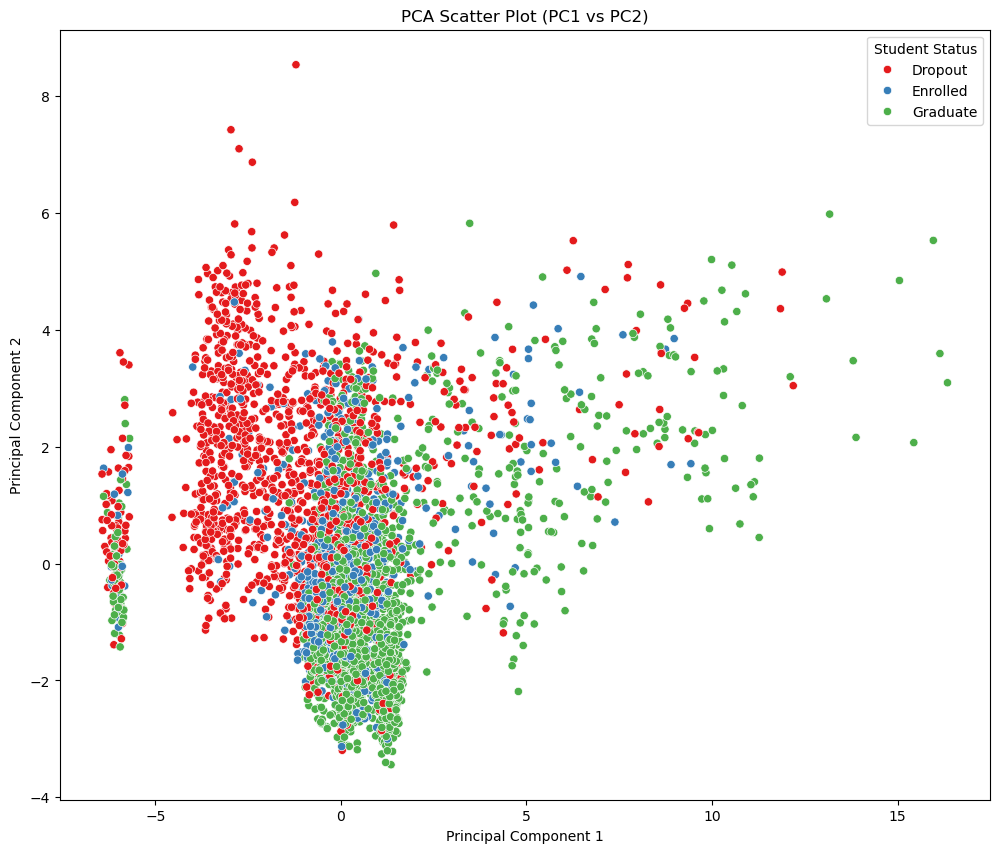

In [110]:
plt.figure(figsize=(12,10))

sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='Target',palette='Set1')

plt.title('PCA Scatter Plot (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Student Status')
plt.show()

The **principal component analysis (PCA)** scatter plot, which compares PC1 and PC2, does not show a clear separation among the student categories, specifically Dropout, Enrolled, and Graduate. The data points largely overlap, indicating that the primary distinctions between these groups are not strongly represented by the initial two principal components.

This suggests that the overall variability within the dataset is spread across several dimensions, an observation consistent with the cumulative explained variance results.

These findings align with the exploratory data analysis (EDA), where some differences between groups were noted, such as in age and academic performance, but these were not substantial enough to form distinct clusters.

Moreover, the extensive overlap between the groups could account for potential limitations in the performance of classification models, including logistic regression, given that the data points are not easily separable.

## 11. Practical application testing

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Target
y = student_df_clean['Target']
X = student_no_label.copy()

# Split original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
# Split PCA

pca_model = PCA(n_components=n_components)
X_pca = pca_model.fit_transform(student_scaled)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



# Train with original data
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_original = accuracy_score(y_test, y_pred)

# Train with PCA data
model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_pca_train, y_pca_train)
y_pred_pca = model_pca.predict(X_pca_test)
acc_pca = accuracy_score(y_pca_test, y_pred_pca)

print("Accuracy (Original):", acc_original)
print("Accuracy (PCA):", acc_pca)

Accuracy (Original): 0.7446327683615819
Accuracy (PCA): 0.7502824858757062


C:\Users\admin 2023\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


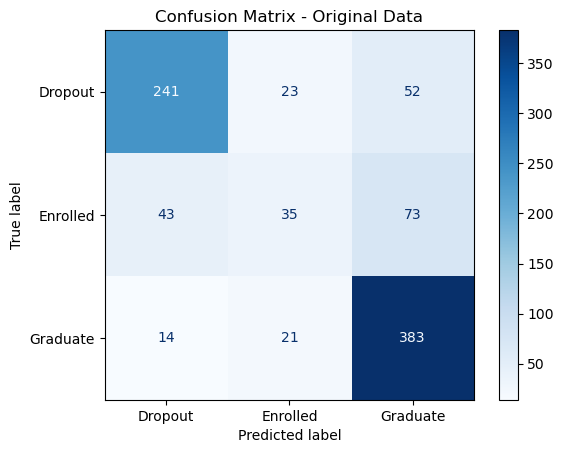

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Original Data')
plt.show()

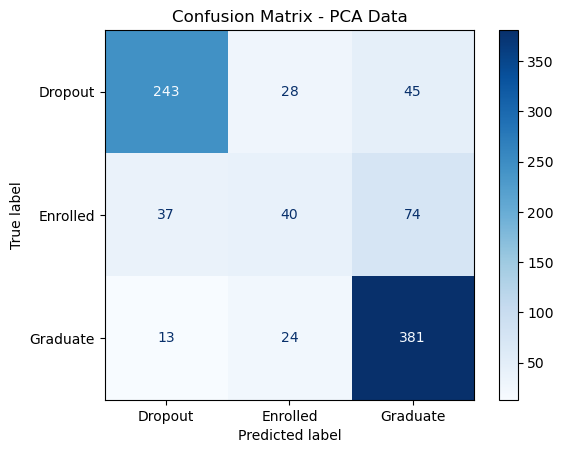

In [115]:
cm_pca = confusion_matrix(y_pca_test, y_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=model_pca.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - PCA Data')
plt.show()

In [116]:
from sklearn.metrics import classification_report

print("Classification Report - Original Data")
print(classification_report(y_test, y_pred))

print("Classification Report - PCA Data")
print(classification_report(y_pca_test, y_pred_pca))

Classification Report - Original Data
              precision    recall  f1-score   support

     Dropout       0.81      0.76      0.79       316
    Enrolled       0.44      0.23      0.30       151
    Graduate       0.75      0.92      0.83       418

    accuracy                           0.74       885
   macro avg       0.67      0.64      0.64       885
weighted avg       0.72      0.74      0.72       885

Classification Report - PCA Data
              precision    recall  f1-score   support

     Dropout       0.83      0.77      0.80       316
    Enrolled       0.43      0.26      0.33       151
    Graduate       0.76      0.91      0.83       418

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.65       885
weighted avg       0.73      0.75      0.73       885



### Testing and Evaluation of PCA

To determine how effective PCA truly was, a Logistic Regression model was applied to both the dataset in its original form and the version that had undergone PCA transformation. The outcomes indicated that the model developed using the original dataset attained an accuracy of roughly 0.75. A comparable accuracy, approximately 0.75, was also observed when the model was applied to the PCA-transformed dataset. Such a finding implies that PCA proved successful in reducing the dataset's dimensionality without significantly compromising its most crucial information. The slight disparity in performance further suggests that the streamlined dataset offers nearly the same effectiveness as its original form, yet benefits from enhanced efficiency and reduced complexity. Thus, PCA demonstrates an advantageous trade-off, balancing the need for dimensionality reduction with the objective of preserving strong model performance.

## Curse of dimensionality

The "curse of dimensionality" occurs when data gains more dimensions as variables are added to the dataset. As often explained, each new variable introduced creates a new dimension in the data space. This means that as dimensionality increases, data points become more dispersed, making it increasingly difficult to identify patterns. The Hughes phenomenon illustrates that models perform best with an optimal number of variables; thus, overly complex models risk overfitting, while overly simple models may underfit. For the present dataset, the relatively high number of features points to the potential manifestation of the curse of dimensionality. Principal Component Analysis (PCA) showed that a considerable number of components were still needed to retain 99.5% of the total variance. This finding suggests that the dataset on student performance encompasses complex information distributed across multiple variables, rather than being highly redundant. Although Principal Component Analysis (PCA) is a useful tool for dimensionality reduction, it does not completely eliminate the challenges inherent in high-dimensional data. Therefore, while dimensionality reduction undeniably improves dataset characteristics, certain effects of the "curse of dimensionality" may still persist.

## 12. Summary of Findings

The project involved the preparation and analysis of a student dataset. Our approach included standard data preparation techniques, exploratory data analysis, and the application of Principal Component Analysis (PCA) for dimensionality reduction.

Initially, the dataset was characterized by examining its structure, the total number of variables, and the inherent data quality. Missing values and identified inconsistencies were subsequently addressed through the application of appropriate data cleaning techniques, thereby enhancing the reliability and consistency of the dataset. Exploratory Data Analysis (EDA) yielded crucial insights into both the distribution of individual variables and their relationships with the designated target variable. This phase was instrumental in developing a deeper comprehension of data patterns and consequently informed the direction of subsequent analytical decisions.

Principal Component Analysis (PCA) was subsequently employed to reduce the dataset's dimensionality, successfully retaining 99.5% of the total variance. The outcomes suggested the necessity of a comparatively large number of components, thereby indicating that the dataset comprises intricate information widely distributed across numerous variables. In this context, the "curse of dimensionality" was recognized as a pertinent challenge, primarily due to the dataset's extensive number of features. While PCA effectively contributed to dimensionality reduction, it did not entirely mitigate the inherent complexity of the data.

To assess the efficacy of PCA, a Logistic Regression model was applied to both the original and the dimensionally reduced datasets. The resulting accuracy values were remarkably similar, thereby demonstrating that the process of dimensionality reduction did not notably compromise model performance. In conclusion, this analysis substantiates that PCA serves as an effective technique for simplifying high-dimensional datasets while substantially preserving salient information. This approach enhances analytical efficiency and facilitates more manageable data analysis.

## 13.Conclusion

The main objective of this project was to analyze student data in detail to understand what truly influences students' academic performance, especially whether they drop out, remain enrolled, or graduate. In the initial data exploration (using Exploratory Data Analysis - EDA), some differences were noted between the student groups, particularly regarding age and academic performance. However, these differences were not sufficiently distinct to clearly separate one group from another, suggesting that the data itself is quite complex.

The application of Principal Component Analysis (PCA) essentially corroborated what was observed previously. The way the variance accumulated indicated the need for a considerable number of components to explain most of the variation, implying that this variability is distributed across many different factors. Furthermore, the PCA scatter plot clearly showed a large overlap between the groups, highlighting that these categories are not easily distinguishable in simpler representations.

During the practical application phase, logistic regression models were used on both the original data and the data transformed by PCA. It was found that the model using the PCA-transformed data showed slightly better performance in terms of accuracy. This suggests that reducing the number of dimensions helped improve the model's performance by eliminating irrelevant information and repetitions.

Even with this improvement, the classification results indicated that the model had difficulty correctly identifying certain groups. Specifically, the "Enrolled" group showed a low recall rate and was frequently misclassified. This implies that the distinctions between this group and the others are quite subtle and are not easily captured by a simple model.

Overall, the exploratory data analysis, Principal Component Analysis (PCA), and the classification model are quite consistent. All point to the idea that predicting student performance is a complex task, shaped by many interconnected factors. Although PCA led to a modest improvement in model performance, exploring more sophisticated models is advisable. For future studies, it is necessary to consider the use of more advanced classification models, such as decision trees, random forests, or gradient boosting. These approaches may be more suitable for identifying the non-linear relationships present in the data.


## References

Bellman, R., 1961. *Adaptive Control Processes*. Princeton University Press.

Jolliffe, I.T., 2002. *Principal Component Analysis*. 2nd ed. New York: Springer.

James, G., Witten, D., Hastie, T. and Tibshirani, R., 2021. *An Introduction to Statistical Learning*. Springer.

Kuhn, M. and Johnson, K., 2019. *Feature Engineering and Selection*. CRC Press.

Dasu, T. and Johnson, T., 2003. *Exploratory Data Mining and Data Cleaning*. Wiley.

McKinney, W. (2017) Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. 2nd edn. Sebastopol: O’Reilly Media.